# Teste de treinamento de modelo para predição de Resistência utilizando HGBR

In [1]:
%%capture
!pip install catboost ipywidgets optuna shapS

In [2]:
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, KFold
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
from google.colab import drive
import os, optuna, shap
import seaborn as sns
import pandas as pd
import numpy as np

### Montagem do drive

In [3]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/resistencia'
filename = 'df_resistencia_CatBoost.pkl'
file_path = os.path.join(dirpath, filename)
os.listdir(dirpath)
df = pd.read_pickle(file_path)
df['target'] = df['Resistencia_Compressao_MPa'].copy()
df.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   Cimento_kg_m3                   599 non-null    float64 
 1   Agregado_Graudo_Total_kg_m3     599 non-null    float64 
 2   Superplastificante_kg_m3        554 non-null    float64 
 3   Relacao_Agua_Cimento            599 non-null    float64 
 4   ln_Idade                        599 non-null    float64 
 5   Tipo_Molde_Cod                  599 non-null    int64   
 6   Metodo_Emp_Cod                  599 non-null    int64   
 7   Classe_Cim_OpA                  599 non-null    int64   
 8   Relacao_Agua_Aglomerante        599 non-null    float64 
 9   Filer_D50_um                    299 non-null    float64 
 10  D_Max                           432 non-null    float64 
 11  vol_ar_aprisionado              554 non-null    float64 
 12  porosidade_volumetrica

In [5]:
def split_target(df, target):
    df.drop(columns=['bins'], inplace=True, errors='ignore')
    y = df[target].copy()
    df.drop(columns=[target], inplace=True)
    return df, y

In [6]:
# 1. Separa 95% para treino e 5% para a teste (mantendo a proporção da coluna 'bins')
df_temp, df_test= train_test_split(
    df,
    test_size=0.05, 
    random_state=42, 
    stratify=df['bins']
)

# 2. Dos 95% restantes, divide em treino e validação, mantendo a proporção da coluna 'bins'
# Isso resulta em 70% do total para treino e 30% para validação
df_train, df_val = train_test_split(
    df_temp, 
    test_size=0.3,
    random_state=42, 
    stratify=df_temp['bins']
)

df_train.to_pickle(os.path.join(dirpath, 'df_train.pkl'))
df_test.to_pickle(os.path.join(dirpath, 'df_test.pkl'))
df_val.to_pickle(os.path.join(dirpath, 'df_val.pkl'))

X_train, y_train = split_target(df_train, 'target')
X_test, y_test = split_target(df_test, 'target')
X_val, y_val = split_target(df_val, 'target')

In [7]:
print(sum([df_train.isna().sum(), df_test.isna().sum(), df_val.isna().sum()]))

Cimento_kg_m3                       0
Agregado_Graudo_Total_kg_m3         0
Superplastificante_kg_m3           45
Relacao_Agua_Cimento                0
ln_Idade                            0
Tipo_Molde_Cod                      0
Metodo_Emp_Cod                      0
Classe_Cim_OpA                      0
Relacao_Agua_Aglomerante            0
Filer_D50_um                      300
D_Max                             167
vol_ar_aprisionado                 45
porosidade_volumetrica_inicial     45
concentracao_agregados              0
finos_total                         0
aglomerante_total                   0
agua_solidos                        0
range_granulometrico              399
parametro_feret                    45
idade_ac_feret                     45
dtype: int64


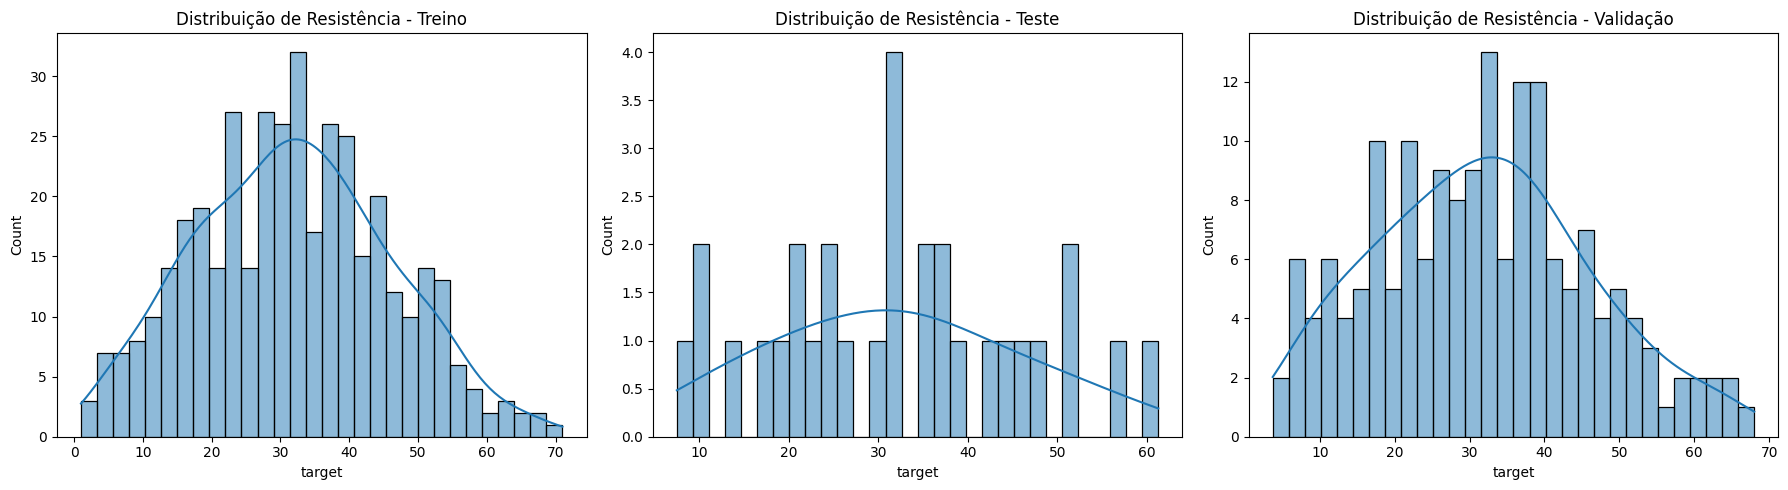

In [8]:
figure, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(y_train, bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribuição de Resistência - Treino')
sns.histplot(y_test, bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribuição de Resistência - Teste')
sns.histplot(y_val, bins=30, kde=True, ax=axes[2])
axes[2].set_title('Distribuição de Resistência - Validação')
plt.tight_layout()
plt.show()

In [9]:
print(f"X_train shape: {X_train.shape}\nX_test shape: {X_test.shape}\nX_val shape: {X_val.shape}\n")
assert X_train.columns.equals(X_test.columns) and X_train.columns.equals(X_val.columns), "As colunas dos DataFrames de treino, teste e validação não são iguais."
print("X_train" + "\n" + "\n".join(f"{c}: {X_train[c].dtype} (NAs: {X_train[c].isna().sum()})" for c in X_train.columns) + "\n")
print("X_test" + "\n" + "\n".join(f"{c}: {X_test[c].dtype} (NAs: {X_test[c].isna().sum()})" for c in X_test.columns) + "\n")
print("X_val" + "\n" + "\n".join(f"{c}: {X_val[c].dtype} (NAs: {X_val[c].isna().sum()})" for c in X_val.columns) + "\n")

X_train shape: (398, 20)
X_test shape: (30, 20)
X_val shape: (171, 20)

X_train
Cimento_kg_m3: float64 (NAs: 0)
Agregado_Graudo_Total_kg_m3: float64 (NAs: 0)
Superplastificante_kg_m3: float64 (NAs: 29)
Relacao_Agua_Cimento: float64 (NAs: 0)
ln_Idade: float64 (NAs: 0)
Tipo_Molde_Cod: int64 (NAs: 0)
Metodo_Emp_Cod: int64 (NAs: 0)
Classe_Cim_OpA: int64 (NAs: 0)
Relacao_Agua_Aglomerante: float64 (NAs: 0)
Filer_D50_um: float64 (NAs: 206)
D_Max: float64 (NAs: 106)
vol_ar_aprisionado: float64 (NAs: 29)
porosidade_volumetrica_inicial: float64 (NAs: 29)
concentracao_agregados: float64 (NAs: 0)
finos_total: float64 (NAs: 0)
aglomerante_total: float64 (NAs: 0)
agua_solidos: float64 (NAs: 0)
range_granulometrico: float64 (NAs: 270)
parametro_feret: float64 (NAs: 29)
idade_ac_feret: float64 (NAs: 29)

X_test
Cimento_kg_m3: float64 (NAs: 0)
Agregado_Graudo_Total_kg_m3: float64 (NAs: 0)
Superplastificante_kg_m3: float64 (NAs: 2)
Relacao_Agua_Cimento: float64 (NAs: 0)
ln_Idade: float64 (NAs: 0)
Tipo_M

In [10]:
print(f"y_train shape: {y_train.shape}\ny_test shape: {y_test.shape}\ny_val shape: {y_val.shape}\n")
print("y_train" + "\n" + f"{y_train.name}: {y_train.dtype} (NAs: {y_train.isna().sum()})" + "\n")
print("y_test" + "\n" + f"{y_test.name}: {y_test.dtype} (NAs: {y_test.isna().sum()})" + "\n")
print("y_val" + "\n" + f"{y_val.name}: {y_val.dtype} (NAs: {y_val.isna().sum()})" + "\n")

y_train shape: (398,)
y_test shape: (30,)
y_val shape: (171,)

y_train
target: float64 (NAs: 0)

y_test
target: float64 (NAs: 0)

y_val
target: float64 (NAs: 0)



In [11]:
hyper_params = {
    'iterations': 800,             # Equivalente ao n_estimators.
    'learning_rate': 0.05,
    'depth': 2,                    # Mantendo nossa "fortaleza" intocável
    'l2_leaf_reg': 10,             # Regularização pesada (equivalente ao reg_lambda)
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'random_seed': 42,
    # O Sistema anti-overfitting do CatBoost
    'od_type': 'Iter',             # Ativa o detector de overfitting (Overfitting Detector)
    'od_wait': 50                  # Se a validação não melhorar por 50 iterações, ele interrompe a busca
}

In [12]:
model = CatBoostRegressor(**hyper_params)

In [13]:
%%time
model.fit(X_train, y_train,
    eval_set=(X_val, y_val),    # Aqui sim podemos passar o X_val externo livremente!
    use_best_model=True,        # Salva apenas a melhor iteração, descartando o resto
    plot=True,                  # Renderiza o painel dinâmico em tempo real
    verbose=False
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

CPU times: user 485 ms, sys: 21.9 ms, total: 506 ms
Wall time: 713 ms


CatBoostRegressor(depth=2, eval_metric='RMSE', iterations=800, l2_leaf_reg=10, learning_rate=0.05, loss_function='RMSE', od_type='Iter', od_wait=50, random_seed=42)

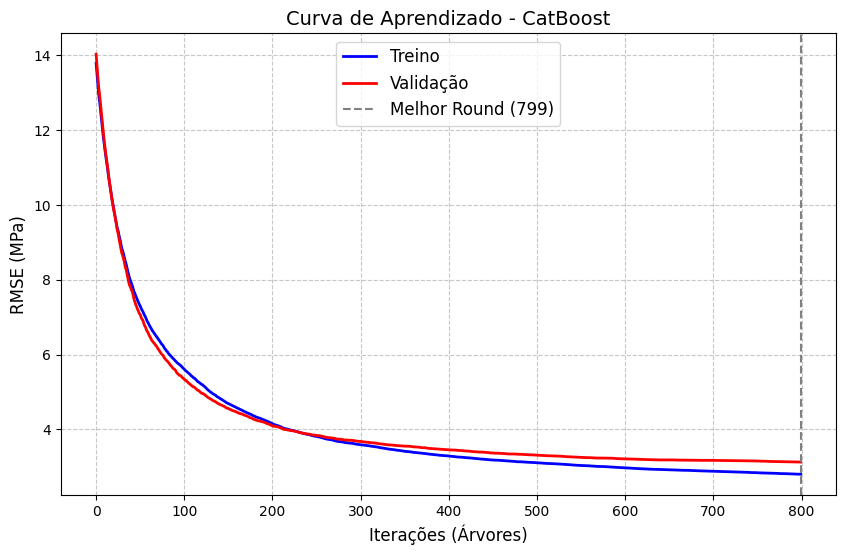

✅ Treinamento concluído. O modelo rebobinou automaticamente para o round 799.
RMSE Final (Treino): 2.7983
RMSE Final (Validação): 3.1240


In [14]:
# 3. Extraindo os históricos gravados dentro do modelo
train_rmse = model.evals_result_['learn']['RMSE']
val_rmse = model.evals_result_['validation']['RMSE']
# Extraímos os dados do histórico interno do modelo treinado
treino_rmse = model.evals_result_['learn']['RMSE']
val_rmse = model.evals_result_['validation']['RMSE']
melhor_round = model.get_best_iteration()

# Criamos nosso próprio gráfico com Matplotlib
plt.figure(figsize=(10, 6))
plt.plot(treino_rmse, label='Treino', color='blue', linewidth=2)
plt.plot(val_rmse, label='Validação', color='red', linewidth=2)

# Coloca uma linha vertical marcando onde foi o melhor round!
plt.axvline(x=melhor_round, color='gray', linestyle='--', label=f'Melhor Round ({melhor_round})')

plt.title('Curva de Aprendizado - CatBoost', fontsize=14)
plt.xlabel('Iterações (Árvores)', fontsize=12)
plt.ylabel('RMSE (MPa)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 3. O Veredito final
print(f"✅ Treinamento concluído. O modelo rebobinou automaticamente para o round {melhor_round}.")
print(f"RMSE Final (Treino): {treino_rmse[melhor_round]:.4f}")
print(f"RMSE Final (Validação): {val_rmse[melhor_round]:.4f}")

In [15]:
# Estatísticas finais
train_final = train_rmse[-1]
val_final = val_rmse[-1]
overfitting_gap = val_final - train_final

print("\n" + "="*60)
print("📊 ANÁLISE DE OVERFITTING E PERFORMANCE")
print("="*60)
print(f"✅ RMSE Treino (final):      {train_final:.6f}")
print(f"⚠️  RMSE Validação (final):   {val_final:.6f}")
print(f"📈 Gap (Val - Train):        {overfitting_gap:.6f}")
print("="*60)


📊 ANÁLISE DE OVERFITTING E PERFORMANCE
✅ RMSE Treino (final):      2.798295
⚠️  RMSE Validação (final):   3.124015
📈 Gap (Val - Train):        0.325720


In [16]:
# Fazer predições no conjunto de teste
y_pred = model.predict(X_test)
debug_df = X_test.copy()

debug_df["pred"] = y_pred
debug_df["ground_truth"] = y_test
debug_df["residual"] = debug_df["ground_truth"] - debug_df["pred"]

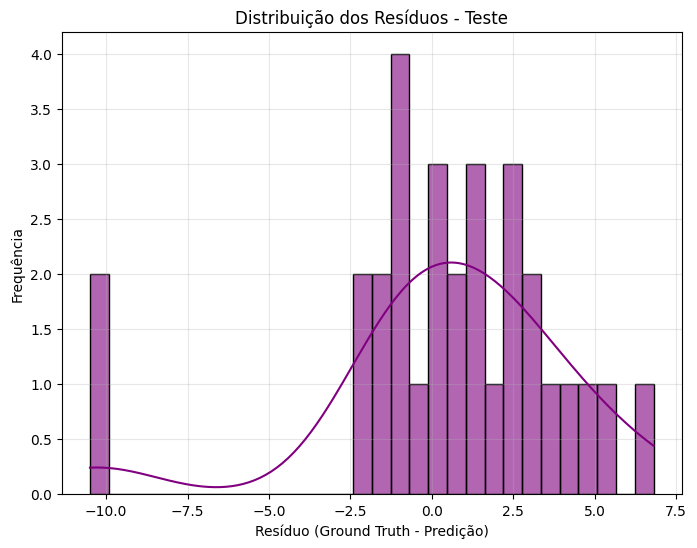

In [17]:
plt.figure(figsize=(8, 6))
sns.histplot(debug_df["residual"], bins=30, kde=True, color='purple', alpha=0.6)
plt.title("Distribuição dos Resíduos - Teste")
plt.xlabel("Resíduo (Ground Truth - Predição)")
plt.ylabel("Frequência")
plt.grid(True, alpha=0.3)
plt.show()

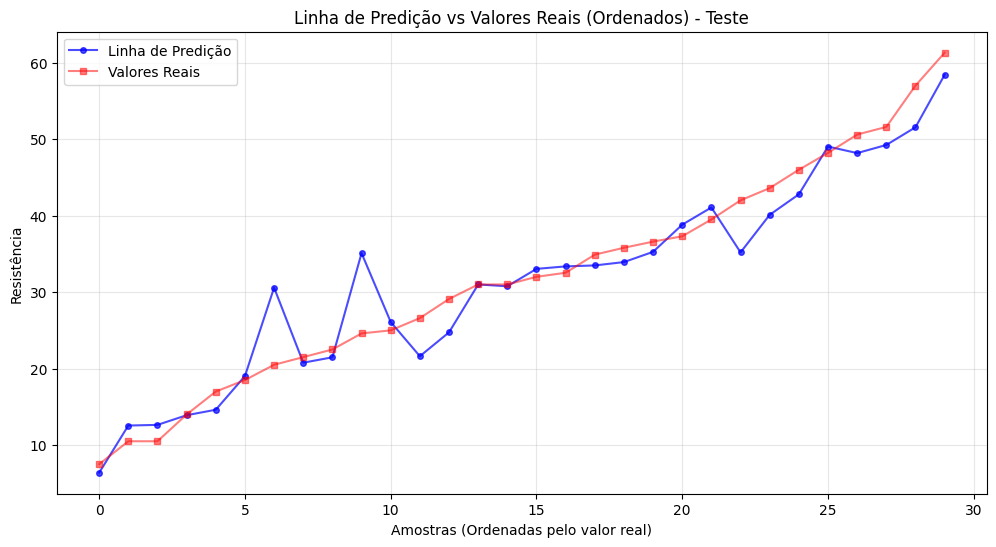

In [18]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = debug_df.sort_values(by="ground_truth").reset_index(drop=True)
indices = range(len(debug_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, debug_df["pred"], color='blue', label="Linha de Predição", 
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, debug_df["ground_truth"], color='red', label="Valores Reais", 
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados) - Teste")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Resistência")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
r2 = r2_score(debug_df["ground_truth"], debug_df["pred"])
rmse = root_mean_squared_error(debug_df["ground_truth"], debug_df["pred"])
mae = mean_absolute_error(debug_df["ground_truth"], debug_df["pred"])
mape = mean_absolute_percentage_error(debug_df["ground_truth"], debug_df["pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 3.6844
mean_absolute_error: 2.6114
mean_absolute_percentage_error: 0.0981
R² Score: 92.9388


In [20]:
y_val_pred = model.predict(X_val)
validation_df = X_val.copy()

validation_df["pred"] = y_val_pred
validation_df["ground_truth"] = y_val
validation_df["residual"] = validation_df["ground_truth"] - validation_df["pred"]

Text(0.5, 1.0, 'Distribuição dos Resíduos - Validação')

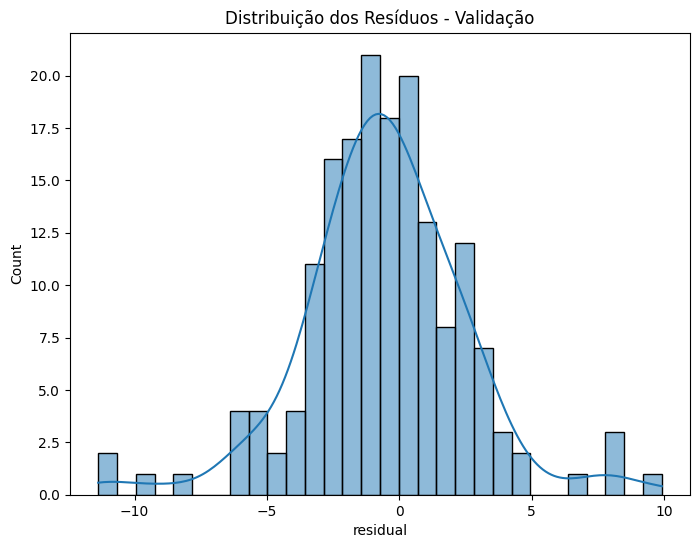

In [21]:
plt.figure(figsize=(8, 6))
sns.histplot(validation_df["residual"], bins=30, kde=True)
plt.title("Distribuição dos Resíduos - Validação")

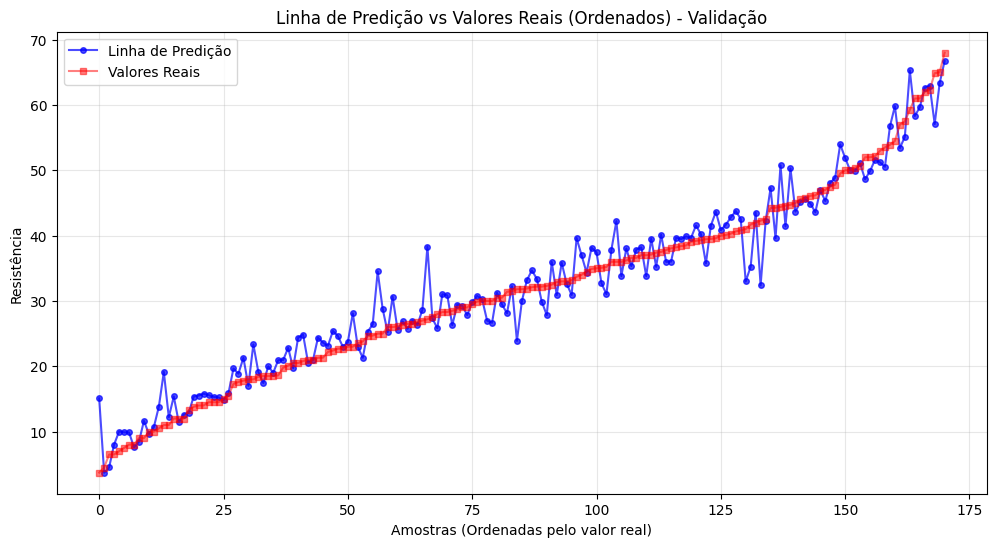

In [22]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
validation_df = validation_df.sort_values(by="ground_truth").reset_index(drop=True)
indices = range(len(validation_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, validation_df["pred"], color='blue', label="Linha de Predição", 
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, validation_df["ground_truth"], color='red', label="Valores Reais", 
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados) - Validação")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Resistência")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
r2 = r2_score(validation_df["ground_truth"], validation_df["pred"])
rmse = root_mean_squared_error(validation_df["ground_truth"], validation_df["pred"])
mae = mean_absolute_error(validation_df["ground_truth"], validation_df["pred"])
mape = mean_absolute_percentage_error(validation_df["ground_truth"], validation_df["pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 3.1240
mean_absolute_error: 2.2945
mean_absolute_percentage_error: 0.1039
R² Score: 95.2297


In [24]:
model_path = os.path.join(dirpath, "melhor_modelo_resistencia.json")
model.save_model(model_path)
print(f"✅ Modelo salvo em: {model_path}")
print(f"\n📋 Informações do Modelo:")
print(f"  • Número de features: {model.n_features_in_}")

✅ Modelo salvo em: /content/drive/MyDrive/supervised-learning-studies/projeto/resistencia/melhor_modelo_resistencia.json

📋 Informações do Modelo:
  • Número de features: 20


/tmp/ipykernel_15647/4065326967.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Feature', data=df_importancia, palette='viridis')


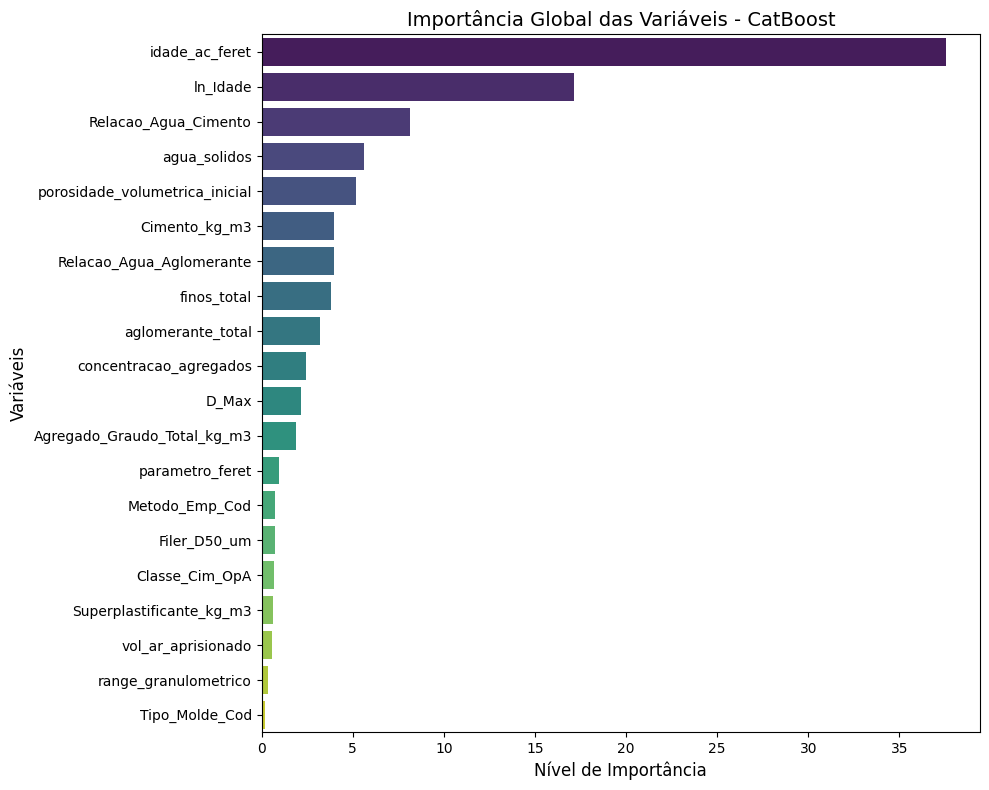

In [25]:
importancias = model.get_feature_importance()
features = X_train.columns

df_importancia = pd.DataFrame({'Feature': features, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importancia', y='Feature', data=df_importancia, palette='viridis')
plt.title('Importância Global das Variáveis - CatBoost', fontsize=14)
plt.xlabel('Nível de Importância', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.tight_layout()
plt.show()